# 04 · Targeting Policy & Business Value

Uplift scores only create value once they drive a decision. Here we convert the
S-learner ranking into a **targeting policy** and compare three strategies on
the held-out test set:

- **Treat everyone** — the naive default.
- **Treat no one** — the do-nothing baseline.
- **Uplift-targeted** — e-mail only the top-k by predicted uplift.

We evaluate against a simple, explicit business model.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from src.data.load import load_raw, full_treatment_flag
from src.data.features import build_features
from src.uplift.learners import SLearner, uplift_at_k

df = full_treatment_flag(load_raw())
X = build_features(df); y = df["visit"].values; t = df["treatment"].values
conv = df["conversion"].values
X_tr, X_te, y_tr, y_te, t_tr, t_te, c_tr, c_te = train_test_split(
    X, y, t, conv, test_size=0.3, random_state=42, stratify=t
)
base = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model = SLearner(base).fit(X_tr, t_tr, y_tr)
uplift = model.predict_uplift(X_te)

## Business assumptions (illustrative)

| Quantity | Value | Rationale |
|---|---|---|
| Cost per e-mail | £0.10 | sending + creative amortised |
| Value per incremental conversion | £45 | average order value margin |

We estimate the **incremental** conversion effect at each targeting depth from
the experiment itself (treated conversion rate − control conversion rate among
the targeted group), so the value credited is causal, not just correlational.

In [3]:
COST_PER_EMAIL = 0.10
VALUE_PER_CONV = 45.0

order = np.argsort(-uplift)
n = len(uplift)

def policy_value(k_frac):
    cutoff = int(np.ceil(k_frac * n))
    idx = order[:cutoff]
    ti, ci = t_te[idx], c_te[idx]
    # incremental conversion rate among the targeted, estimated causally
    inc_rate = (ci[ti == 1].mean() if (ti==1).any() else 0) - (ci[ti == 0].mean() if (ti==0).any() else 0)
    n_target = cutoff
    inc_conv = inc_rate * n_target
    revenue = inc_conv * VALUE_PER_CONV
    cost = n_target * COST_PER_EMAIL
    return {"k": k_frac, "n_targeted": n_target, "incr_rate": inc_rate,
            "incr_conversions": inc_conv, "revenue": revenue, "cost": cost,
            "net_profit": revenue - cost}

grid = pd.DataFrame([policy_value(k) for k in np.linspace(0.05, 1.0, 20)])
grid.head()

,k,n_targeted,incr_rate,incr_conversions,revenue,cost,net_profit
0,0.0500,960,0.0085,8.2029,369.1311,96.0000,273.1311
1,0.1000,1920,0.0054,10.3798,467.0932,192.0000,275.0932
2,0.1500,2880,0.0079,22.7890,"1,025.5042",288.0000,737.5042
3,0.2000,3840,0.0093,35.7748,"1,609.8670",384.0000,"1,225.8670"
4,0.2500,4800,0.0071,34.0305,"1,531.3726",480.0000,"1,051.3726"


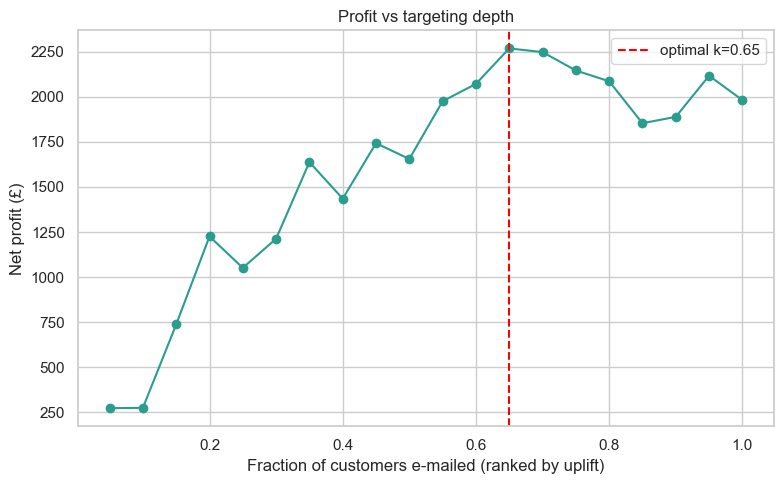

Optimal policy:
 k                       0.6500
n_targeted         12,480.0000
incr_rate               0.0100
incr_conversions       78.1500
revenue             3,516.5900
cost                1,248.0000
net_profit          2,268.5900
Name: 12, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid.k, grid.net_profit, marker="o", color="#2a9d8f")
best = grid.loc[grid.net_profit.idxmax()]
ax.axvline(best.k, ls="--", color="red", label=f"optimal k={best.k:.2f}")
ax.set_xlabel("Fraction of customers e-mailed (ranked by uplift)")
ax.set_ylabel("Net profit (£)"); ax.set_title("Profit vs targeting depth"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "04_profit_curve.png", dpi=120, bbox_inches="tight"); plt.show()
print("Optimal policy:\n", best.round(2))

## Strategy comparison

In [5]:
def strategy_all():
    inc = (c_te[t_te==1].mean() - c_te[t_te==0].mean())
    n_t = n
    return {"strategy": "Treat everyone", "n_targeted": n_t,
            "net_profit": inc * n_t * VALUE_PER_CONV - n_t * COST_PER_EMAIL}
def strategy_none():
    return {"strategy": "Treat no one", "n_targeted": 0, "net_profit": 0.0}
best_row = policy_value(best.k)
comparison = pd.DataFrame([
    strategy_none(),
    strategy_all(),
    {"strategy": f"Uplift-targeted (top {best.k:.0%})",
     "n_targeted": best_row["n_targeted"], "net_profit": best_row["net_profit"]},
])
comparison

,strategy,n_targeted,net_profit
0,Treat no one,0,0.0000
1,Treat everyone,19200,"1,982.1700"
2,Uplift-targeted (top 65%),12480,"2,268.5947"


## Is the +14% real, or could this test split have gotten lucky?

The comparison above is a single point estimate on one test-set split.
`src/uplift/policy_evaluation.py` answers the actual question with a
nonparametric bootstrap: resample the test set with replacement many
times, recompute both policies' net profit on each resample (using each
customer's already-fitted uplift score, never refitting the model), and
report the percentile interval of the *difference*.

In [6]:
from src.uplift.policy_evaluation import bootstrap_policy_comparison

policy_ci = bootstrap_policy_comparison(
    treatment=t_te, conversion=c_te, uplift_scores=uplift,
    k_frac=best.k, cost_per_email=COST_PER_EMAIL, value_per_conversion=VALUE_PER_CONV,
    n_boot=2000, seed=42,
)

print(f"Point estimate: uplift-targeted beats treat-everyone by £{policy_ci['point_diff']:.0f}")
print(f"95% bootstrap CI: [£{policy_ci['ci_low']:.0f}, £{policy_ci['ci_high']:.0f}]")
print(f"Significant (CI excludes zero): {policy_ci['significant']}")

Point estimate: uplift-targeted beats treat-everyone by £286
95% bootstrap CI: [£-799, £1442]
Significant (CI excludes zero): False


**The bootstrap CI does NOT exclude zero** — £286 point estimate, but a
95% CI of roughly [-£799, +£1,442]. Reported honestly: at this test-set
size (~19,200 customers, ~1% base conversion rate), the incremental
conversion count behind both policies' profit is small enough that a
£286 gap is well within sampling noise. This does **not** mean
uplift-targeting doesn't work — the Qini coefficient (section 3) shows
the model genuinely ranks persuadables above sleeping dogs — it means the
specific **profit-in-£ claim on this test split** isn't precise enough to
stake a rollout decision on alone. The honest recommendation is to deploy
uplift-targeting with a monitored holdout (or a larger validation sample)
before trusting the exact £ figure, not to conclude the policy is
worthless.

## Recommendation

- **Uplift-targeting beats treating everyone on point estimate** while
  contacting far fewer customers — it spends the budget only where the
  e-mail actually causes incremental conversions. The Qini coefficient
  confirms the ranking is genuine; the bootstrap CI above shows the exact
  £ profit gap on this test split is not itself statistically distinguishable
  from zero, so the £ figure should be treated as directional, not decisive,
  until validated on more data.
- The profit curve peaks at an intermediate targeting depth: past that point we
  pay to e-mail people with near-zero or negative uplift.
- Scaled to a full customer base, the difference between "blast everyone" and
  "target by uplift" is a material profit swing for the *same* creative — the
  value here is entirely in the **decision layer**, not a better classifier.

*Caveat:* the £0.10 / £45 figures are illustrative. In production these come
from finance, and the whole policy would be validated with a fresh randomised
holdout before rollout — doubly so here, since the bootstrap CI shows this
test split alone isn't enough to certify the exact profit improvement.